# SETTING UP THE NOTEBOOK ENVIRONMENT FOR STATISTICS COMPUTATION

In [1]:
## A.Install libraries into our environment to be used for Manipulation of our data
!pip install numpy
!pip install pandas 
!pip install matplotlib
!pip install seaborn

In [4]:
## A.Import libraries into our environment to be used for Manipulation of our data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## For Statistical Analysis AND Computation we install special libraries
- SCIPY Library has advanced capabilities for Statistical and Mathematical Analysis.
- STATSMODELS allows to work with Statistical Models.

In [6]:
##Install Special packages to enable us calculate some statistics
!pip install scipy
!pip install statsmodels

In [7]:
## Lets us import the newly installed packages into our environment
import scipy
import statsmodels.api as sm

In [8]:
## Lets us also import statistics library  into our environment
import statistics as stats

In [10]:
## Import our data into our environment
jobs_df = pd.read_csv(r"C:\Users\Gifton\Videos\0.0002 DATA ANALYTICS\2026, APRIL PROJECTS\103 PROJECT(JOB SALARIES)\job_salary_prediction_dataset.csv")
jobs_df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [11]:
## Create A Copy of our Data Frame which we'll be using and refer to the Original Copy incase of Mistakes
jobs_df1 = jobs_df.copy()
jobs_df1

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [12]:
## Check for our column Names
jobs_df1.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [13]:
## In this Notebook Project, we'll be mainly interested in Statistical Analysis and Computations
## Fist let us check for data types of our columns
jobs_df1.dtypes

job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
remote_work         object
certifications       int64
salary               int64
dtype: object

In [14]:
## Categorize Categorical and Numerical Columns Separately
numerical_cols = jobs_df1.select_dtypes(include = ['int64'])
categorical_cols = jobs_df1.select_dtypes(include =['object'])

In [15]:
## We Obtain DESCRIPTIVES for both Numerical and Categorical columns data types
numerical_stats = numerical_cols.describe()
numerical_stats


,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [16]:
categorical_stats = categorical_cols.describe()
categorical_stats

,job_title,education_level,industry,company_size,location,remote_work
count,250000,250000,250000,250000,250000,250000
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Large,Australia,No
freq,21125,50352,25393,50254,25258,83621


## PART B: Statistical Analysis and Computations

### Q1. Find the average, naximum, minimum and Inter-quartile ranges employees salaries across the job titles

In [17]:
avg_salary = jobs_df1['salary'].mean().round(0)
avg_salary


np.float64(145718.0)

In [18]:
## What is the Maximum Employee Salary
max_salary = jobs_df1['salary'].max()
max_salary

333046

In [20]:
## What is the Minimum Employee Salary
min_salary = jobs_df1['salary'].min()
min_salary

31867

In [21]:
## What is the Interquartile Range of employee salary
IQR = max_salary - min_salary
IQR

301179

### Q2. Calculate the standard deviation of employee salaries across the job titles

In [23]:
# The standard deviation for Employee Salary
salary_dev = jobs_df1['salary'].std()
salary_dev
    # For a standard deviation of approximately 37407 implies that most employees across job titles earn 37407 from the average salary.
    #The Highest salary is approximately 183K, while the Lowest salary is approximately 108K

37407.95272924413

In [38]:
jobs_df1.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

### Q3. How does the average job titles salaries compare with sampled job titles
- In this case we shall compare the entire population mean (N) and then using Random Sampling in Statistics to obtain sample mean(n) for comparative studies

In [25]:
## For the entire population (N)
salary_estimate1 = jobs_df1['salary'].mean()
salary_estimate1


np.float64(145718.080524)

In [28]:
## Sampling with Python: lETS simulate a random sample(n of 50 job titles)
sampled_jobs = jobs_df1.sample(n=50, replace=True, random_state=31208)
sampled_jobs

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
140903,Business Analyst,4,High School,8,Retail,Medium,Netherlands,Yes,3,93613
244563,Cybersecurity Analyst,14,Diploma,4,Media,Large,Remote,Hybrid,4,150113
72914,Cloud Engineer,10,High School,3,Technology,Startup,Canada,No,5,131476
154473,Cybersecurity Analyst,9,Master,7,Government,Large,Australia,No,1,154539
109237,Backend Developer,10,Bachelor,17,Technology,Enterprise,Remote,Yes,3,163928
19804,Business Analyst,0,High School,2,Finance,Enterprise,Sweden,No,1,75580
166136,Business Analyst,17,Diploma,19,Telecom,Enterprise,UK,Yes,3,192875
191764,AI Engineer,17,High School,19,Consulting,Small,Netherlands,Yes,0,167224
138590,Data Analyst,17,Master,9,Media,Enterprise,Australia,No,5,159027
210172,Cloud Engineer,6,Bachelor,12,Healthcare,Startup,UK,No,3,136309


In [29]:
## Check for any rows that might have been duplicated
sampled_jobs.duplicated()
## Result: There are no duplicates

140903    False
244563    False
72914     False
154473    False
109237    False
19804     False
166136    False
191764    False
138590    False
210172    False
153610    False
125406    False
178814    False
160910    False
4093      False
19373     False
10547     False
145629    False
87124     False
66430     False
136025    False
243500    False
228755    False
27902     False
51471     False
15616     False
110839    False
173807    False
213835    False
202019    False
220849    False
232786    False
137379    False
73490     False
85516     False
14086     False
199025    False
188844    False
247149    False
187377    False
64036     False
105086    False
180927    False
144709    False
112114    False
203448    False
155050    False
162461    False
19053     False
86384     False
dtype: bool

In [30]:
## Compute the MEAN SALARY for the Sampled Jobs and AS Estimate_1 Variable
sampled_estimate = sampled_jobs['salary'].mean()
sampled_estimate


np.float64(138394.86)

### For comparatibility purposes we generate two more samples

In [31]:
## Again we generate a new sample of 50 jobs as Estimate_2 and compute the Mean(). Case using  a different random number say 56800
sampled_jobs2 = jobs_df1['salary'].sample(n=50, replace=True, random_state=56800).mean()
sampled_jobs2

np.float64(145028.5)

In [32]:
## Lastly, we Compute a sampling distributions with 10,000 samples of 50 Job Titles and compute the Mean
estimate_list= []
for i in range(10000):
    estimate_list.append(jobs_df1['salary'].sample(n=50, replace=True).mean())

estimate_df = pd.DataFrame(data={'estimate':estimate_list}).mean()
estimate_df

## Result explanation: When using The POPULATION SALARY MEAN OF(145718) is almost identical to the Sampling Distribution SALARY MEAN OF(145674)

estimate    145827.030966
dtype: float64

### Q4. Visualize the data showing Population Salary Versus Sampled Population Salary

C:\Users\Gifton\AppData\Local\Temp\ipykernel_412\3511164495.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(estimate_list, label='Sampled Jobs-Salary Distribution',


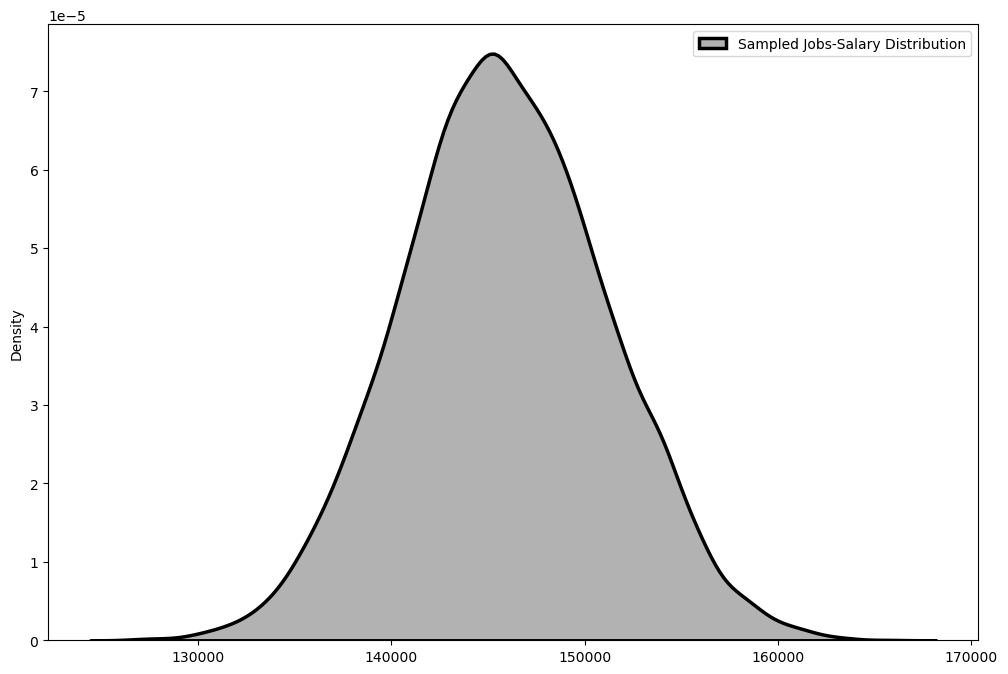

In [33]:
## 1. Sampling Distribution Plot Visualization

plt.figure(figsize=(12,8))
sns.kdeplot(estimate_list, label='Sampled Jobs-Salary Distribution', 
            linewidth=2.5, fill=True, color='black', shade=True, alpha=0.3)
plt.legend()
plt.show()

C:\Users\Gifton\AppData\Local\Temp\ipykernel_412\262105268.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(jobs_df1['salary'], label='Population Jobs-Salary Distribution',


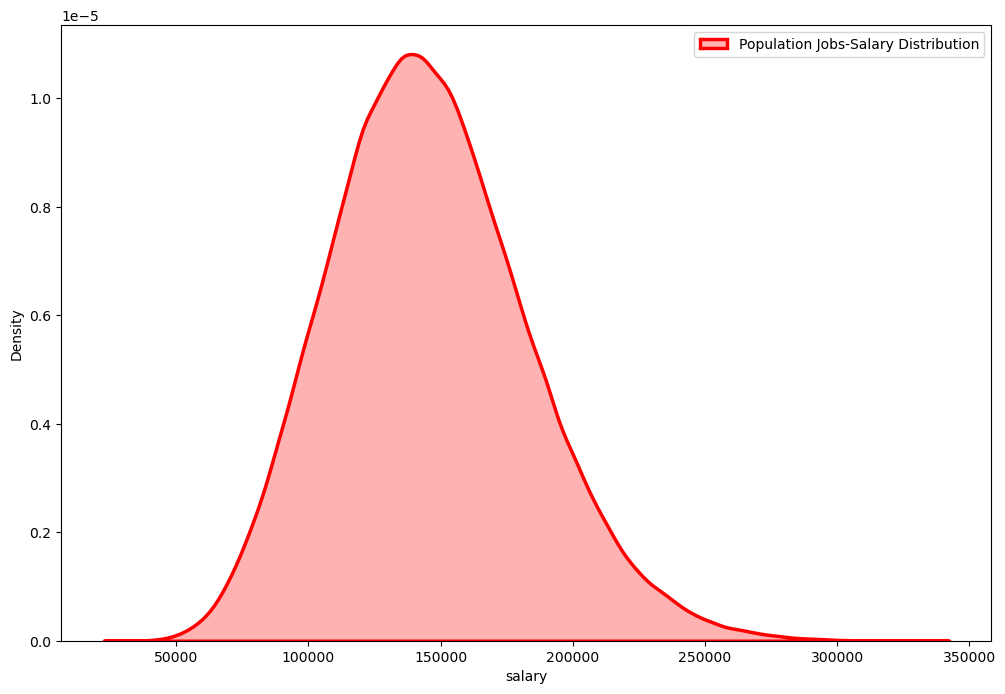

In [34]:
## 2. The Entire Population (N) Visual Plots
plt.figure(figsize=(12,8))
sns.kdeplot(jobs_df1['salary'], label='Population Jobs-Salary Distribution', 
            linewidth=2.5, color='red', shade=True, alpha=0.3)
plt.legend()
plt.show()

## Result: The Sampling Distribution mirrors and is very identical to the Actual Population distribution. They both exhibit a Normal Distribution curve.

### Q5. Construct a Confidence interval for the first estimate during the  random sampling processes

In [35]:
## CALCULATING CONFIDENCE INTERVALS FOR OUR VERY FIRST SAMPLE (n=50 and random_state as 31208)
## Lets again calculate the Mean Job salary for the svery FIRST SAMPLED DATA and store it as an Estimate_mean variable
Estimate_1 = sampled_jobs['salary'].mean()
Estimate_1


np.float64(138394.86)

In [36]:
## Import STATS library for Confidence Interval calculations
import scipy.stats as stats

In [37]:
## Create a New Variable to first calculate the estimated standard error
estimated_standard_error=sampled_jobs['salary'].std(ddof=1)/np.sqrt(sampled_jobs.shape[0])
estimated_standard_error

np.float64(5074.155938254406)

In [38]:
## Then we CONSTRUCT A 95% Confidence Interval
confidence_interval = stats.norm.interval(confidence=0.95, loc=Estimate_1, scale=estimated_standard_error)
confidence_interval

    #The Estimate_1 is the n=50 Random Samples

(np.float64(128449.6971090813), np.float64(148340.02289091866))

In [40]:
## Construct a 99% confidence interval for our Sample Job Salary Data
confidence_interval = stats.norm.interval(confidence=0.99, loc=Estimate_1, scale=estimated_standard_error)
confidence_interval

    #Explanation: On comparison of the two Confidence Intervals, as the Level increases so does the Interval gets even wider. They help Show how jobs salaries are distributed across the spectrum.

(np.float64(125324.70044346762), np.float64(151465.01955653235))